In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('athlete_events.csv', on_bad_lines='skip', low_memory=False)
region_df = pd.read_csv('noc_regions.csv')

In [ ]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [ ]:
df.shape

(89283, 15)

In [ ]:
df = df[df['Season'] == 'Summer']

In [ ]:
df.shape

(74197, 15)

In [ ]:
df = df.merge(region_df,on = 'NOC',how = 'left')

In [ ]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN


In [ ]:
df['region'].unique()

array(['China', 'Denmark', 'Netherlands', 'Finland', 'Norway', 'Romania',
       'Estonia', 'France', 'Morocco', 'Spain', 'Egypt', 'Iran',
       'Bulgaria', 'Italy', 'Chad', 'Azerbaijan', 'Sudan', 'Russia',
       'Argentina', 'Cuba', 'Belarus', 'Greece', 'Cameroon', 'Turkey',
       'Chile', 'Mexico', 'USA', 'Nicaragua', 'Hungary', 'Nigeria',
       'Algeria', 'Kuwait', 'Bahrain', 'Pakistan', 'Iraq', 'Syria',
       'Lebanon', 'Qatar', 'Malaysia', 'Germany', 'Canada', 'Ireland',
       'Australia', 'South Africa', 'Eritrea', 'Tanzania', 'Jordan',
       'Tunisia', 'Libya', 'Belgium', 'Djibouti', 'Palestine', 'Comoros',
       'Kazakhstan', 'Brunei', 'India', 'Saudi Arabia', 'Maldives',
       'Ethiopia', 'United Arab Emirates', 'Yemen', 'Indonesia',
       'Philippines', nan, 'Uzbekistan', 'Kyrgyzstan', 'Tajikistan',
       'Japan', 'Republic of Congo', 'Switzerland', 'Brazil', 'Monaco',
       'Israel', 'Uruguay', 'Sweden', 'Sri Lanka', 'Armenia',
       'Ivory Coast', 'Kenya', 'Ben

In [ ]:
df.duplicated().sum()

np.int64(526)

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(73671, 17)

In [ ]:
df['Medal'].value_counts()

,count
Medal,
Gold,3688
Bronze,3636
Silver,3579


In [ ]:
df = pd.concat([df,pd.get_dummies(df['Medal'])],axis = 1)
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,False,False,False
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,False,False,False
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,False,False,False
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,False,True,False
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN,False,False,False


In [ ]:
df[['Bronze', 'Gold', 'Silver']] = df[['Bronze', 'Gold', 'Silver']].astype(int)
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,0,0,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,0,0,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,0,0,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,0,1,0
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN,0,0,0


In [ ]:
df.shape

(73671, 20)

In [ ]:
df.groupby('NOC').sum()[['Gold','Silver','Bronze']].sort_values('Gold',ascending = False).reset_index()

,NOC,Gold,Silver,Bronze
0,USA,883,472,420
1,ITA,240,217,226
2,GBR,236,254,224
3,FRA,227,267,283
4,URS,197,155,168
...,...,...,...,...
223,WIF,0,0,1
224,YEM,0,0,0
225,YAR,0,0,0
226,YMD,0,0,0


In [ ]:
medal_tally = df.drop_duplicates(subset = ['Team','NOC','Games','Year','Sport','Event','Medal','Season'],inplace = True)

In [ ]:
medal_tally = df.groupby('region').sum()[['Gold','Silver','Bronze']].sort_values('Gold',ascending = False).reset_index()
medal_tally

,region,Gold,Silver,Bronze
0,USA,507,359,306
1,Germany,212,180,197
2,Russia,194,173,174
3,France,144,144,176
4,UK,143,170,153
...,...,...,...,...
198,Venezuela,0,1,7
199,"Virgin Islands, British",0,0,0
200,"Virgin Islands, US",0,0,0
201,Yemen,0,0,0


In [ ]:
medal_tally['Total'] = medal_tally['Gold'] + medal_tally['Silver'] + medal_tally['Bronze']
medal_tally

,region,Gold,Silver,Bronze,Total
0,USA,507,359,306,1172
1,Germany,212,180,197,589
2,Russia,194,173,174,541
3,France,144,144,176,464
4,UK,143,170,153,466
...,...,...,...,...,...
198,Venezuela,0,1,7,8
199,"Virgin Islands, British",0,0,0,0
200,"Virgin Islands, US",0,0,0,0
201,Yemen,0,0,0,0


In [ ]:
df['Year'].unique()

array([1992, 2012, 1920, 1900, 1932, 1952, 2000, 1996, 1912, 1924, 1948,
       2008, 2016, 2004, 1984, 1968, 1972, 1988, 1936, 1956, 1960, 1928,
       1976, 1980, 1964, 1906, 1904, 1908, 1896])

In [ ]:
# Convert the Year column to numeric, forcing non-numeric values (like 'Summer', 'London') to NaN
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Extract unique years, drop NaN values, convert to integer, and sort
years = sorted(df['Year'].dropna().astype(int).unique().tolist())

In [ ]:
# Display the cleaned and sorted list of years
print(years)

[1896, 1900, 1904, 1906, 1908, 1912, 1920, 1924, 1928, 1932, 1936, 1948, 1952, 1956, 1960, 1964, 1968, 1972, 1976, 1980, 1984, 1988, 1992, 1996, 2000, 2004, 2008, 2012, 2016]


In [ ]:
years.insert(0,'Overall')
years

['Overall',
 1896,
 1900,
 1904,
 1906,
 1908,
 1912,
 1920,
 1924,
 1928,
 1932,
 1936,
 1948,
 1952,
 1956,
 1960,
 1964,
 1968,
 1972,
 1976,
 1980,
 1984,
 1988,
 1992,
 1996,
 2000,
 2004,
 2008,
 2012,
 2016]

In [ ]:
country = np.unique(df['region'].dropna().values).tolist()

In [ ]:
country.sort()

In [ ]:
country.insert(0,'Overall')
country

['Overall',
 'Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Antigua',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Boliva',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Cook Islands',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czech Republic',
 'Democratic Republic of the Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Ethiopia',
 'Fiji',
 'Finland',
 'France',
 'Gabon',
 'Gambia',
 'Georgia',
 'Germany',
 'Ghana',
 'Greece',
 'Grenada',
 'Guam',
 'Guatemala',
 'Gui

In [ ]:
def fetch_medal_tally(year, country):
    medal_df = df.drop_duplicates(subset = ['Team','NOC','Games','Year','Sport','Event','Medal','Season'])
    flag = 0
    if year == 'Overall' and country == 'Overall':
        temp_df = medal_df
    if year == 'Overall' and country != 'Overall':
        flag = 1
        temp_df = medal_df[medal_df['region'] == country]
    if year != 'Overall' and country == 'Overall':
        temp_df = medal_df[medal_df['Year'] == year]
    if year != 'Overall' and country != 'Overall':
        temp_df = medal_df[(medal_df['Year'] == year) & (medal_df['region'] == country)]

    if flag == 1:
        x = temp_df.groupby('Year').sum()[['Gold', 'Silver', 'Bronze']].sort_values('Year', ascending=True).reset_index()
        x['Year'] = x['Year'].astype(int)
    else:
        x = temp_df.groupby('region').sum()[['Gold', 'Silver', 'Bronze']].sort_values('Gold', ascending=False).reset_index()

    x['Total'] = x['Gold'] + x['Silver'] + x['Bronze']
    return x

In [ ]:
fetch_medal_tally(year=2016, country='India')

,region,Gold,Silver,Bronze,Total
0,India,0,0,0,0


In [ ]:
# Overall Analysis:
# 1-Number of editions:
df['Year'].unique().shape[0] - 1

28

In [ ]:
# 2-Number of cities:
df['City'].unique().shape

(23,)

In [ ]:
# 3-Number of events/sports:
df['Sport'].unique().shape

(51,)

In [ ]:
# 4-Number of Athletes:
df['Name'].unique().shape

(27797,)

In [ ]:
# 5-Number of participating notation:
df['region'].unique().shape

(204,)

In [ ]:
nations_over_time = df.drop_duplicates(['Year','region'])['Year'].value_counts().reset_index().sort_values('Year',ascending = False)
nations_over_time.rename(columns = {'Year' : 'Edition','count' : 'Number of countries'},inplace = True)

In [ ]:
nations_over_time


,Edition,Number of countries
2,2016,181
0,2012,187
4,2008,180
1,2004,184
5,2000,177
3,1996,181
7,1992,150
6,1988,151
8,1984,136
14,1980,76


In [ ]:
import plotly.express as px
fig = px.line(nations_over_time,x = 'Edition',y='Number of countries')
fig.show()

In [ ]:
events_over_time = df.drop_duplicates(['Year','Event'])['Year'].value_counts().reset_index().sort_values('Year',ascending = False)
events_over_time.rename(columns = {'Year' : 'Edition','count' : 'Number of events'},inplace = True)

In [ ]:
events_over_time

,Edition,Number of events
0,2016,306
2,2012,302
1,2008,302
4,2004,300
3,2000,300
5,1996,271
6,1992,257
7,1988,237
8,1984,221
9,1980,203


In [ ]:
fig = px.line(events_over_time,x = 'Edition',y='Number of events')
fig.show()

In [ ]:
athlete_over_time = df.drop_duplicates(['Year','Name'])['Year'].value_counts().reset_index().sort_values('Year',ascending = False)
athlete_over_time.rename(columns = {'Year' : 'Edition','count' : 'Number of athlete'},inplace = True)
athlete_over_time

,Edition,Number of athlete
0,2016,2714
2,2012,2569
1,2008,2589
4,2004,2480
3,2000,2532
5,1996,2429
6,1992,2254
7,1988,2067
8,1984,1699
13,1980,1201


In [ ]:
fig = px.line(athlete_over_time,x = 'Edition',y='Number of athlete')
fig.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# plt.figure(figsize = (25,25))
# sns.heatmap(df.pivot_table(index = 'Sport',columns = 'Year',values = 'Event',aggfunc = 'count').fillna(0).astype(int),annot = True)
# # plt.show()


In [ ]:
x = df.drop_duplicates(['Year','Sport','Event'])

<Axes: xlabel='Year', ylabel='Sport'>

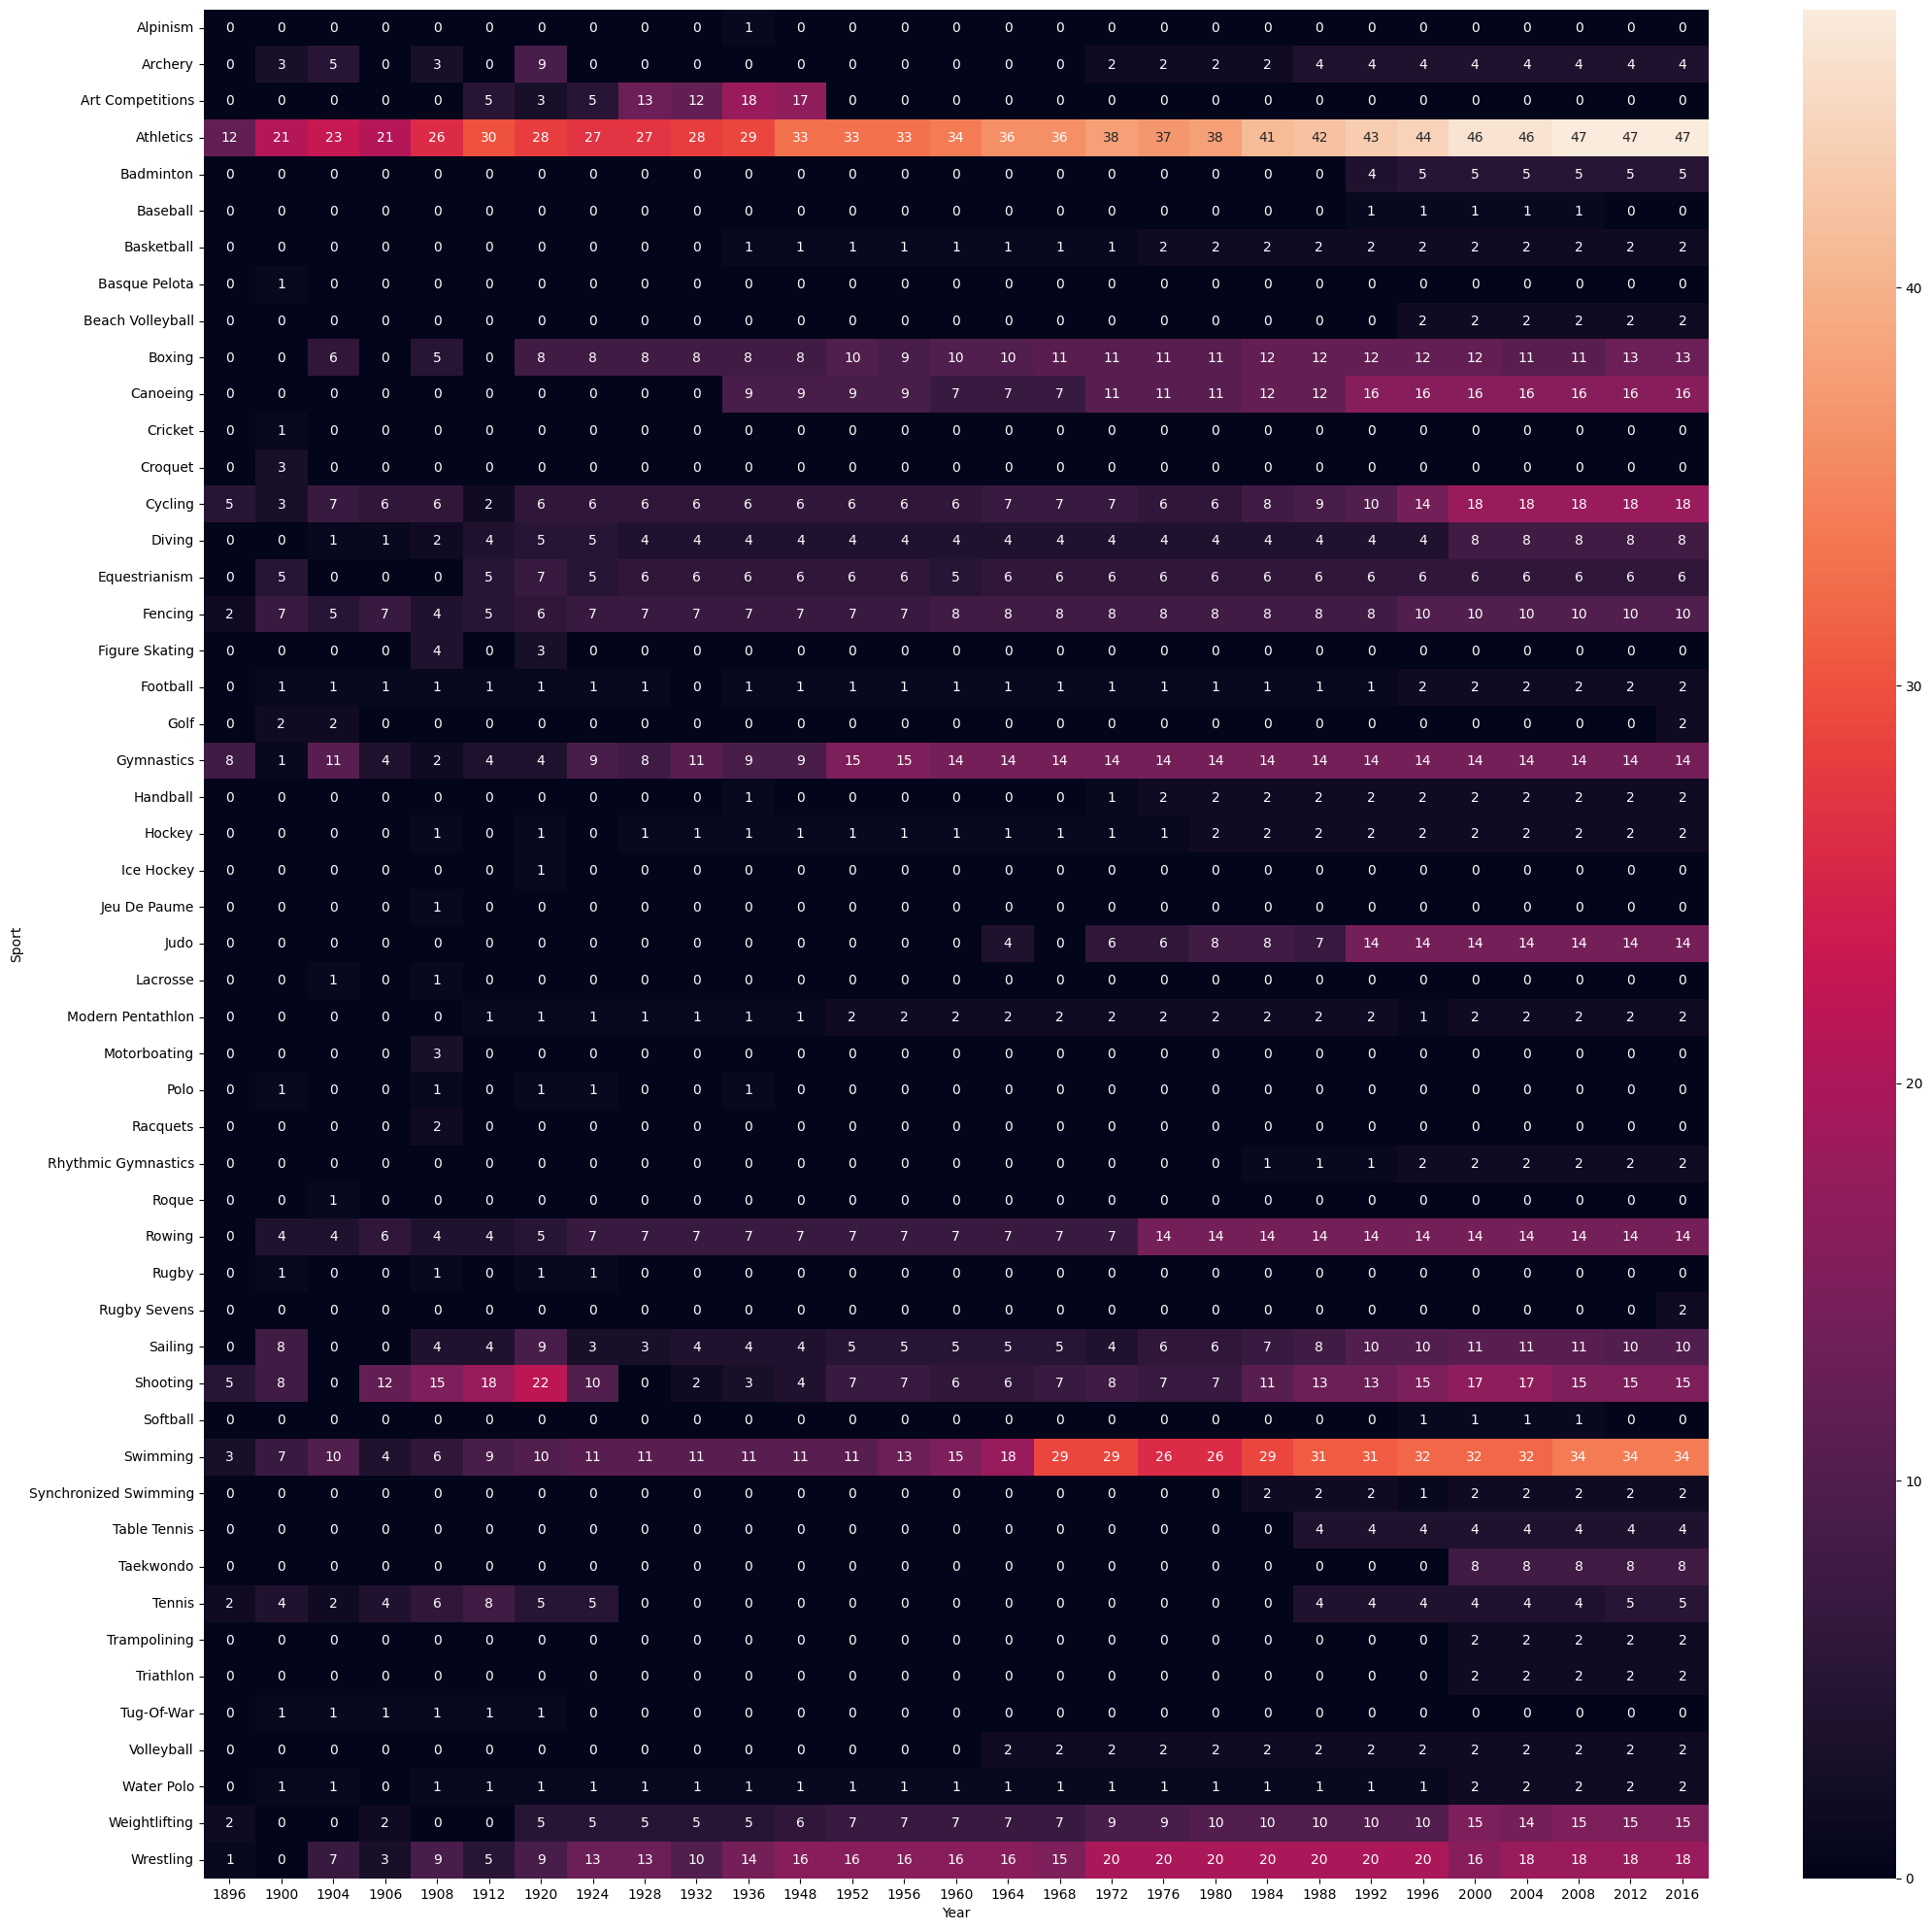

In [ ]:
plt.figure(figsize = (25,25))
sns.heatmap(x.pivot_table(index = 'Sport',columns = 'Year',values = 'Event',aggfunc='count').fillna(0).astype(int),annot = True)

In [ ]:
def most_successful(df, sport):
    temp_df = df.dropna(subset=['Medal'])

    if sport != 'Overall':
        temp_df = temp_df[temp_df['Sport'] == sport]

    # value_counts().reset_index() returns columns: [original_column_name, 'count']
    # which in this case are 'Name' and 'count'
    top_athletes = temp_df['Name'].value_counts().reset_index().head(15)

    # Merge back with the original DataFrame on the athlete's Name
    merged_df = top_athletes.merge(df, on='Name', how='left')

    # Select and deduplicate based on athlete's Name
    result = merged_df[['Name', 'count', 'Sport', 'region']].drop_duplicates('Name')
    result.rename(columns={'count': 'Medals'}, inplace=True)
    return result

In [ ]:
most_successful(df,'Gymnastics')

,Name,Medals,Sport,region
0,Nikolay Yefimovich Andrianov,15,Gymnastics,Russia
24,Polina Hryhorivna Astakhova,10,Gymnastics,Russia
43,Vra slavsk (-Odloilov),10,Gymnastics,Czech Republic
56,Viktor Ivanovych Chukarin,9,Gymnastics,Russia
66,Nadia Elena Comneci (-Conner),9,Gymnastics,Romania
78,Aleksandr Nikolayevich Dityatin,8,Gymnastics,Russia
91,Simona Amnar (-Tabr),7,Gymnastics,Romania
103,George Louis Eyser,6,Gymnastics,USA
109,Yukio Endo,6,Gymnastics,Japan
126,Vladimir Nikolayevich Artyomov,5,Gymnastics,Russia


In [ ]:
# Country-wise:
# 1-Countrywise medal tally per year:
temp_df = df.dropna(subset = ['Medal'])
temp_df.drop_duplicates(subset = ['Team','NOC','Games','Year','City','Sport','Event','Medal'],inplace = True)

/tmp/ipykernel_2265/622462717.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
new_df = temp_df[temp_df['region'] == 'USA']
final_df = new_df.groupby('Year').count()['Medal'].reset_index()

In [ ]:
fig = px.line(final_df,x = 'Year',y = 'Medal')
fig.show()

<Axes: xlabel='Year', ylabel='Sport'>

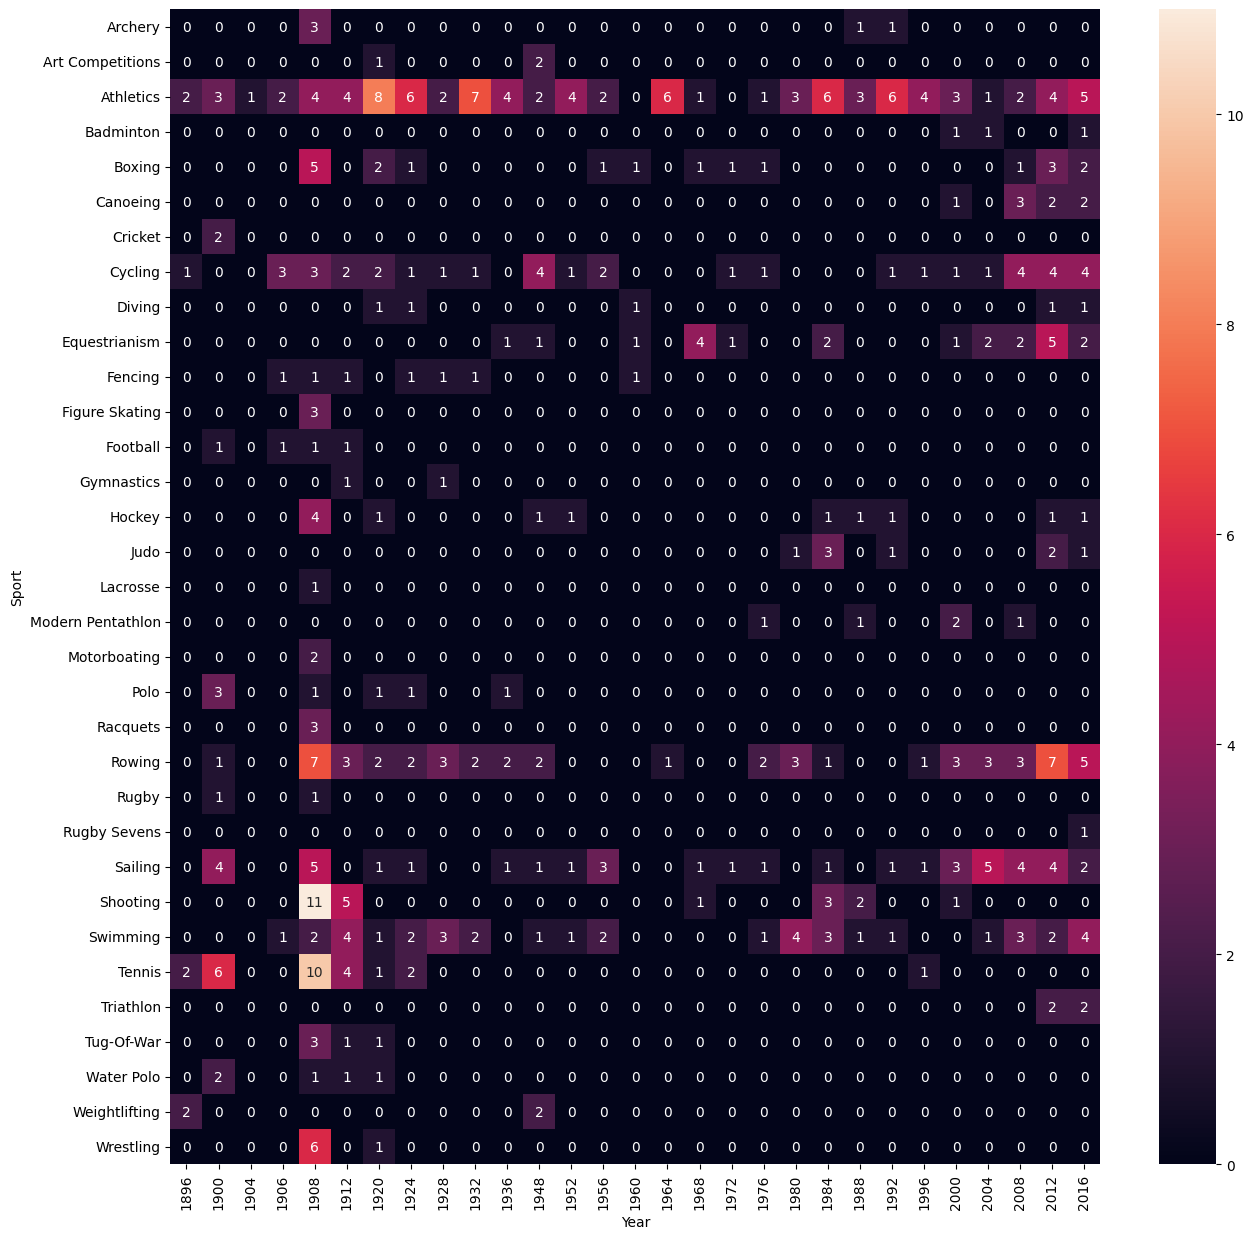

In [ ]:
new_df = temp_df[temp_df['region'] == 'UK']
# final_df = new_df.groupby('Year').count()['Medal'].reset_index()
# fig = px.line(final_df,x = 'Year',y = 'Medal')
# fig.show()
plt.figure(figsize = (15,15))
sns.heatmap(new_df.pivot_table(index = 'Sport',columns = 'Year',values = 'Medal',aggfunc = 'count').fillna(0).astype(int),annot = True)

In [ ]:
# Most successful player countrywise:



In [ ]:
def most_successful_countrywise(df, country):
    # Filter out rows without medals
    temp_df = df.dropna(subset=['Medal'])

    # Filter by the specified country/region
    temp_df = temp_df[temp_df['region'] == country]

    # Count medals per athlete
    top_athletes = temp_df['Name'].value_counts().reset_index().head(15)
    top_athletes.rename(columns={'count': 'Medals'}, inplace=True)

    # Merge back to get the Sport
    merged_df = top_athletes.merge(df, on='Name', how='left')

    # Deduplicate and keep key information
    result = merged_df[['Name', 'Medals', 'Sport']].drop_duplicates('Name')
    return result

In [ ]:
# Demonstrate the function for the USA
most_successful_countrywise(df, 'USA')

,Name,Medals,Sport
0,"Raymond Clarence ""Ray"" Ewry",10,Athletics
10,"Matthew Nicholas ""Matt"" Biondi",9,Swimming
20,Nathan Ghar-Jun Adrian,8,Swimming
28,"Charles Meldrum ""Charlie"" Daniels",8,Swimming
36,Shirley Frances Babashoff,8,Swimming
46,Amanda Ray Beard (-Brown),7,Swimming
55,Natalie Anne Coughlin (-Hall),7,Swimming
62,Burton Cecil Downing,6,Cycling
68,Allyson Michelle Felix,6,Athletics
75,George Louis Eyser,6,Gymnastics


In [ ]:
import plotly.figure_factory as ff

In [ ]:
athlete_df = df.drop_duplicates(subset = ['Name','region'])

In [ ]:
x1 = athlete_df['Age'].dropna()
x2 = athlete_df[athlete_df['Medal'] == 'Gold']['Age'].dropna()
x3 = athlete_df[athlete_df['Medal'] == 'Silver']['Age'].dropna()
x4 = athlete_df[athlete_df['Medal'] == 'Bronze']['Age'].dropna()

In [ ]:
fig = ff.create_distplot([x1,x2,x3,x4],['Overall Age','Gold Medalist','Silver Medalist','Bronze Medalist'],show_hist = False,show_rug = False)
fig.show()

In [ ]:
# Define a list of famous sports to resolve the NameError
famous_sports = [
    'Athletics', 'Swimming', 'Gymnastics', 'Cycling', 'Fencing',
    'Wrestling', 'Shooting', 'Boxing', 'Rowing', 'Football'
]

x = []
name = []
for sport in famous_sports:
  temp_df = athlete_df[athlete_df['Sport'] == sport]
  x.append(temp_df[temp_df['Medal'] == 'Gold']['Age'].dropna())
  name.append(sport)

In [ ]:
fig = ff.create_distplot(x,name,show_hist = False,show_rug = False)
fig.show()

In [ ]:
import plotly.express as px

# Filter for athletes who won medals to focus the plot and prevent overplotting
medalists_df = df.dropna(subset=['Medal']).copy()

# Ensure Height and Weight are available
plot_df = medalists_df.dropna(subset=['Height', 'Weight'])

# We'll take a representative sample of 3000 athletes to keep the interactive plot responsive
if len(plot_df) > 3000:
    plot_df = plot_df.sample(3000, random_state=42)

# Create the interactive scatter plot
fig = px.scatter(
    plot_df,
    x='Weight',
    y='Height',
    color='Medal',
    color_discrete_map={'Gold': '#FFD700', 'Silver': '#C0C0C0', 'Bronze': '#CD7F32'},
    category_orders={'Medal': ['Gold', 'Silver', 'Bronze']},
    hover_data=['Name', 'Sport', 'Event', 'Year', 'region'],
    title='Olympic Athletes: Height vs. Weight by Medal and Sport',
    labels={'Weight': 'Weight (kg)', 'Height': 'Height (cm)'},
    opacity=0.7
)

fig.update_layout(
    legend_title_text='Medal Won',
    template='plotly_white'
)

fig.show()

In [ ]:
import plotly.express as px

# Filter for only medal-winning rows
medals_df = df.dropna(subset=['Medal'])

# Group by Sex and Medal type, and count the occurrences
gender_medals = medals_df.groupby(['Sex', 'Medal']).size().reset_index(name='Count')

# Map 'Sex' to fully readable labels
gender_medals['Sex'] = gender_medals['Sex'].map({'M': 'Male', 'F': 'Female'})

# Create a grouped bar chart
fig = px.bar(
    gender_medals,
    x='Medal',
    y='Count',
    color='Sex',
    barmode='group',
    color_discrete_map={'Male': '#1f77b4', 'Female': '#e377c2'},
    category_orders={'Medal': ['Gold', 'Silver', 'Bronze']},
    title='Olympic Medal Achievements: Male vs. Female Athletes',
    labels={'Count': 'Number of Medals', 'Medal': 'Medal Type'},
    text='Count'
)

fig.update_traces(textposition='outside')
fig.update_layout(
    template='plotly_white',
    xaxis_tickfont_size=14,
    yaxis_title='Number of Medals'
)

fig.show()